# Tracing, static arguments, and recompilation

CPU companion; no accelerator is required. TPU execution not validated.

- Distinguish runtime array values from shape/dtype metadata and static configuration.
- Inspect a staged computation with make_jaxpr.
- Explain a Python value-dependent branch failure under jit.
- Use static configuration or JAX control flow according to the kind of decision.

A function works until you put a Python if statement inside jit. Why does that change things? We’ll separate what Python knows while tracing from what the program learns at runtime. Then you’ll choose between a small static configuration and an array-based decision, rather than making every difficult argument static.

## The idea

Tracing observes how Python builds an array computation from abstract inputs. Static arguments are part of that program-building decision; dynamic array values are data for the resulting computation. Keep a small call ledger to separate these roles.

## Build a call ledger before diagnosing recompilation

Record each call's shape, dtype and static choices next to the observed trace count. Change only values first. Then change one shape, then one static option. This controlled sequence makes a trace increase interpretable; changing everything at once does not.

A Python branch needs a concrete decision during tracing. If the decision is intended to vary with array data at execution time, use an appropriate JAX control-flow operation instead of converting a tracer to a Python boolean. If it genuinely selects a small number of program variants, an explicit static argument may be suitable.

Do not turn every input into a static value to silence an error. Many distinct static values can create many specializations. Trace counts are useful observations, but they are not a universal count of all compilation work or a cross-process cache guarantee.

### Pause and reason

A loop passes a new Python configuration value on every call as a static argument. What should you inspect?

<details><summary>Compare your reasoning</summary>

Inspect whether that value truly changes program structure. If it is ordinary changing data, represent it dynamically where possible. Keep the call ledger and compare traces after changing one factor at a time.

</details>

## Separate metadata, configuration, and data

A tensor shape such as $(3,)$ describes the size of the computation; its values $[1, 2, 3]$ are runtime data. A string mode such as sum describes which computation to construct. In this lesson mode is a small finite configuration, so marking it static is reasonable.

If mode changes rarely while batches change constantly, static configuration lets a stable compiled specialization accept many batches. If you make frequently changing data static, you encourage distinct specializations and may run into hashability constraints. A JAX array is not a convenient static argument just because a Python branch wants to inspect it.

## Read a tiny staged program

make_jaxpr exposes a representation of the traced array operations. A Python print inside the function may run while tracing, but it does not become an ordinary numerical operation in that representation. A multiply and a reduce_sum should appear in a multiply-then-sum example.

The exact printed formatting and primitive names are not a stable teaching contract. Read it for inputs, outputs, and the broad sequence of numerical operations. The point is to observe that the computation is staged, not to memorize an internal dump or treat the representation as a complete performance explanation.

## Why a Python if can fail

Consider if $x$ > $0$ where $x$ is a dynamic scalar argument. Python wants one Boolean immediately to choose which branch to execute while tracing. The tracer represents a runtime value, so that truth test cannot generally be answered at trace time. The resulting conversion error is evidence of a staging mismatch, not evidence that comparisons cannot run on an accelerator.

For a scalar runtime decision, lax.cond expresses the conditional in the numerical program. Its two branches must return compatible structures and shapes/dtypes. Both branch functions are traced; for an ordinary scalar condition the selected branch is the runtime computation. Under batching, a conditional can be transformed into selection behavior, so do not infer cost or side-effect behavior from the Python-like notation alone.

## Make configuration choices explicit

The worked reduce_values function chooses sum or mean using a static mode string. Each mode can have its own specialization. It should reject unknown modes instead of silently treating any typo as mean. This is a small input-contract improvement that prevents plausible-looking wrong results.

Keep function identity stable, configure static_argnames at the transformation boundary, and pass mode deliberately. Shape and dtype changes can also require specializations. Different element values with compatible abstract input properties ordinarily do not, though caches and transformation details make exact global compilation counts a poor public guarantee.

## Inspect tracing without confusing it with runtime logging

A Python print in a jitted function is a trace-time observation. If you call the function again with compatible inputs, its absence is consistent with reuse. It is not a reliable counter of all device executions or all compilations across the application. JAX provides debug facilities for observing runtime values.

Use trace observations for a small diagnostic experiment and rely on supported compiler logging/profiling when investigating a real training job. Do not make application behavior depend on a side effect inside a transformed numerical function.

## Carry this boundary into the next phase

The upcoming state lessons will make randomness, parameter structure, loops, and branches explicit. The same principle applies: information needed at runtime belongs in the numerical state or arguments, while small program configuration can belong in specialization.

Before reaching for a workaround, classify the value and the question: is Python constructing the computation, or is the computation choosing a result based on runtime data? That classification leads to an implementation you can explain and test.

## Run the example

In [1]:
import jax
import jax.numpy as jnp
def reduce_values(x, mode):
    if mode == "sum":
        return x.sum()
    if mode == "mean":
        return x.mean()
    raise ValueError("mode must be sum or mean")
compiled = jax.jit(reduce_values, static_argnames=("mode",))
x = jnp.array([1., 2., 3.])
print("Sum:", float(compiled(x, mode="sum")))
print("Mean:", float(compiled(x, mode="mean")))
assert jnp.allclose(compiled(x, mode="sum"), 6.)
assert jnp.allclose(compiled(x, mode="mean"), 2.)

Sum: 6.0
Mean: 2.0


Expected: Sum: $6.0$; Mean: $2.0$. These mode choices can use separate compiled specializations.

## Static choices select a traced program

Predict: Does changing array data require the same action as changing a Python branch choice?

Conceptual diagram; the arrows are an instructional map.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

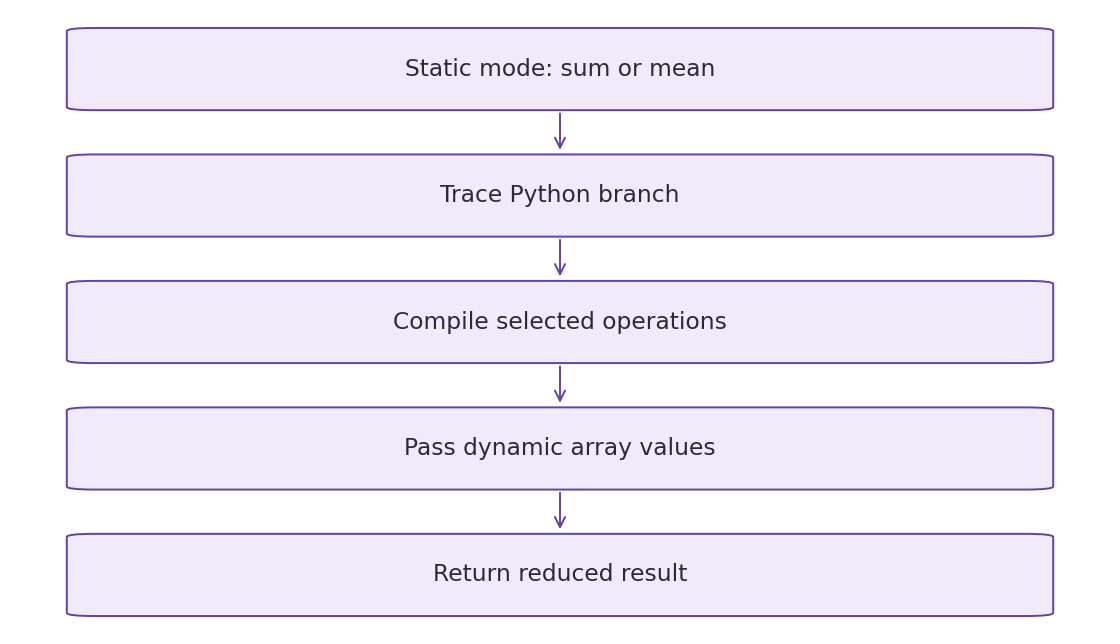

In [2]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

visual_data = {"kind":"flow","nodes":["Static mode: sum or mean","Trace Python branch","Compile selected operations","Pass dynamic array values","Return reduced result"],"layout":"sequence"}
panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Follow the boxes downward. The static mode first selects either summation or averaging. Python follows that branch while JAX traces it, and JAX compiles the operations in the selected branch. Array values then flow through the resulting computation.

For the example array $(1,2,3)$, the sum branch returns $6$ and the mean branch returns $2$. The diagram shows how a program is selected, not a competition between two numerical outputs.

### Connect it to the computation

A compatible later call can reuse the selected program while supplying different array values. Changing the static mode selects a different specialization; changing shapes or dtypes can also require a new specialization. The tracing and compilation boxes therefore do not run on every compatible call.

The arrows describe dependencies, and the box sizes do not encode runtime. Use the trace-count experiment to observe reuse. Merely seeing a different answer after changing the array is not evidence that retracing occurred.

## Look at the staged numerical work

Predict: Predict the operations needed to square and sum a vector. Which part is executed as Python during tracing?

In [3]:
def sum_squares(values):
    print("Tracing sum_squares; shape:", values.shape)
    return jnp.sum(values * values)
print(jax.make_jaxpr(sum_squares)(x))
staged_squares = jax.jit(sum_squares)
assert jnp.allclose(staged_squares(x), 14.)
assert jnp.allclose(staged_squares(x + 1.), 29.)

Tracing sum_squares; shape: (3,)
{ lambda ; a:f32[3]. let
    b:f32[3] = mul a a
    c:f32[] = reduce_sum[axes=(0,) out_sharding=None] b
  in (c,) }


Expected: The representation contains numerical multiplication and reduction. Trace prints can appear during staging, not as one guaranteed print per call.

The second call supplies new values with the same shape/dtype. The numerical result changes while the computation structure can be reused.

## Reproduce and repair a dynamic branch

Predict: For positive and negative scalar inputs, predict the branch result. Why can eager Python decide but tracing cannot?

In [4]:
def python_branch(value):
    if value > 0.:
        return value ** 2
    return -value
assert python_branch(-2.) == 2.
try:
    jax.jit(python_branch)(jnp.array(-2.))
except jax.errors.TracerBoolConversionError:
    print("Expected dynamic Boolean conversion error")
else:
    raise AssertionError("Expected a traced Python branch to fail")
def runtime_branch(value):
    return jax.lax.cond(value > 0., lambda z: z ** 2, lambda z: -z, value)
compiled_branch = jax.jit(runtime_branch)
assert jnp.allclose(compiled_branch(jnp.array(-2.)), 2.)
assert jnp.allclose(compiled_branch(jnp.array(3.)), 9.)

Expected dynamic Boolean conversion error


Expected: The Python branch fails under jit with a tracer Boolean conversion error. The staged conditional returns $2$ and $9$.

The test expects a particular category of error and confirms the repair for both branches. A broad catch-all would hide unrelated failures.

## Your exercise

Foundation · Extend reduce_values with a static max mode while preserving sum and mean. Reject unknown modes. Verify all three modes on $[1, 2, 3]$ and on $[-4, -1, -2]$.

In [5]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [6]:
def choose_reduction(values, mode):
    if mode == "sum":
        return values.sum()
    if mode == "mean":
        return values.mean()
    if mode == "max":
        return values.max()
    raise ValueError("unknown mode")
choose = jax.jit(choose_reduction, static_argnames=("mode",))
for values in (x, jnp.array([-4., -1., -2.])):
    for mode, reference in (("sum", jnp.sum), ("mean", jnp.mean), ("max", jnp.max)):
        assert jnp.allclose(choose(values, mode=mode), reference(values))
try:
    choose(x, mode="typo")
except ValueError:
    pass
else:
    raise AssertionError("Unknown mode should fail")

## Keep runtime values dynamic · Practice

Implement an elementwise absolute value with a numerical selection, jit it, and test mixed-sign vectors. Explain why making the whole vector static is inappropriate.

Hint: `jnp.where` selects elementwise; both candidate arrays are computed expressions. It is not a Python branch per element.

In [7]:
# Write your attempt here.

## Reference reasoning

The vector values are runtime data. Elementwise selection preserves a fixed output shape and does not need a static array.

In [8]:
def elementwise_absolute(values):
    return jnp.where(values >= 0., values, -values)
compiled_absolute = jax.jit(elementwise_absolute)
for values in (jnp.array([-2., 0., 3.]), jnp.array([5., -4., -1.])):
    assert jnp.allclose(compiled_absolute(values), jnp.abs(values))

## Audit a shape-dependent specialization · Challenge

Run a jitted sum-of-squares function for lengths $3$ and $5$, each with two different value sets. Compare to a loop calculation. Explain which changes can affect specialization and which are ordinary runtime data.

Hint: Do not use elapsed time alone to infer whether tracing occurred. Values and shape are different inputs to your reasoning.

In [9]:
# Write your attempt here.

## Reference reasoning

Changing the length changes shape metadata and can need a new specialization. Changing shift changes element values at the same shape/dtype. The test verifies correctness across both kinds of changes without inventing a guaranteed compilation count.

In [10]:
def plain_sum_squares(values):
    return jnp.sum(values ** 2)
compiled_squares = jax.jit(plain_sum_squares)
for length in (3, 5):
    for shift in (0., 1.):
        values = jnp.arange(length, dtype=jnp.float32) + shift
        expected = sum(float(v) ** 2 for v in values)
        assert jnp.allclose(compiled_squares(values), expected)

## Checkpoint

A frequently changing runtime scalar controls a branch. What is the most appropriate first repair for a traced Python if?

1. Mark every runtime scalar static.
2. Express the runtime decision with compatible JAX control flow.
3. Catch every exception and return zero.

## Diagnose

For a tracer Boolean conversion error, inspect the Python truth test. For an unhashable static argument, reconsider whether the object is really configuration. For repeated setup, inspect function recreation, shapes/dtypes, and static values. For missing Python logs, distinguish tracing from runtime execution. Always verify both branches and preserve unknown-mode errors rather than returning a plausible fallback.

## Evidence

Keep the small jaxpr observation, the expected tracer Boolean error, checks of both repaired branches, all static reduction modes including invalid-mode rejection, and shape/value-change cases. Do not infer compilation counts from timing alone.

## Carry forward

- Python executes while staging; numerical array operations form the runtime computation.
- Static configuration and dynamic numerical data have different roles.
- Use runtime control flow for runtime decisions and compatible branch returns.
- Inspect evidence of tracing separately from numerical correctness and timing.

## Primary references

- [JAX: tracing and compilation](https://docs.jax.dev/en/latest/jit-compilation.html)
- [JAX: control flow](https://docs.jax.dev/en/latest/control-flow.html)
- [JAX: tracer Boolean conversion errors](https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerBoolConversionError)